# Materia: Aprendizaje automatico

# Alumno: Moises Lobayza

# Trabajo Práctico: Regularización en modelos de regresión

En este trabajo se estudian distintos métodos de regularización aplicados a modelos de regresión lineal. La regularización es una técnica que permite controlar la complejidad del modelo penalizando el tamaño de sus coeficientes, con el objetivo de reducir el sobreajuste y mejorar la capacidad de generalización.

A partir del tutorial propuesto, se reproducirá el código en Python utilizando bibliotecas de ciencia de datos como pandas, numpy, matplotlib y scikit-learn. Se analizarán los modelos Ridge, Lasso y Elastic Net, comparando su funcionamiento, sus diferencias y sus resultados.

El objetivo principal es comprender cómo estos métodos modifican el comportamiento de una regresión lineal tradicional y cómo permiten obtener modelos más estables, especialmente cuando existen muchos predictores o variables correlacionadas.

# Librerías

In [75]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8
import seaborn as sns

# Preprocesado y modelado
# ==============================================================================
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('once')


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Carga de datos

El set de datos contiene 101 columnas. Las 100 primeras, nombradas como
V
1
, ...,
V
100
 recogen el valor de absorbancia para cada una de las 100 longitudes de onda analizadas (predictores), y la columna fat el contenido en grasa medido por técnicas químicas (variable respuesta).

In [76]:
file_id = "1fmyg8nvxqHZ77AVCNuXUoIx8GXbDFAXR"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

datos = pd.read_csv(url)
display(datos.head())

,Unnamed: 0,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V92,V93,V94,V95,V96,V97,V98,V99,V100,fat
0,1,2.61776,2.61814,2.61859,2.61912,2.61981,2.62071,2.62186,2.62334,2.62511,...,2.98145,2.96072,2.94013,2.91978,2.89966,2.87964,2.85960,2.83940,2.81920,22.5
1,2,2.83454,2.83871,2.84283,2.84705,2.85138,2.85587,2.86060,2.86566,2.87093,...,3.29186,3.27921,3.26655,3.25369,3.24045,3.22659,3.21181,3.19600,3.17942,40.1
2,3,2.58284,2.58458,2.58629,2.58808,2.58996,2.59192,2.59401,2.59627,2.59873,...,2.68951,2.67009,2.65112,2.63262,2.61461,2.59718,2.58034,2.56404,2.54816,8.4
3,4,2.82286,2.82460,2.82630,2.82814,2.83001,2.83192,2.83392,2.83606,2.83842,...,2.97367,2.94951,2.92576,2.90251,2.87988,2.85794,2.83672,2.81617,2.79622,5.9
4,5,2.78813,2.78989,2.79167,2.79350,2.79538,2.79746,2.79984,2.80254,2.80553,...,3.30025,3.27907,3.25831,3.23784,3.21765,3.19766,3.17770,3.15770,3.13753,25.5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Relación entre variables

El primer paso a la hora de establecer un modelo lineal múltiple es estudiar la **relación que existe entre variables**. Esta información es crítica a la hora de identificar cuáles pueden ser los mejores predictores para el modelo, y para detectar colinealidad entre predictores. A modo complementario, es recomendable representar la distribución de cada variable mediante histogramas.

In [77]:
# Correlación entre columnas numéricas
# ==============================================================================

def tidy_corr_matrix(corr_mat):
    '''
    Función para convertir una matriz de correlación de pandas en formato tidy
    '''
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1','variable_2','r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)

    return(corr_mat)

corr_matrix = datos.select_dtypes(include=['float64', 'int']) \
              .corr(method='pearson')
display(tidy_corr_matrix(corr_matrix).head(5))


,variable_1,variable_2,r,abs_r
1031,V10,V11,0.999996,0.999996
1132,V11,V10,0.999996,0.999996
1235,V12,V11,0.999996,0.999996
1134,V11,V12,0.999996,0.999996
928,V9,V10,0.999996,0.999996


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**En esta sección se calcula la correlación de Pearson entre las variables numéricas del dataset. Luego, la matriz de correlación se transforma en una tabla ordenada para identificar fácilmente qué pares de variables presentan mayor relación lineal entre sí.**

# Heatmap matriz de correlaciones

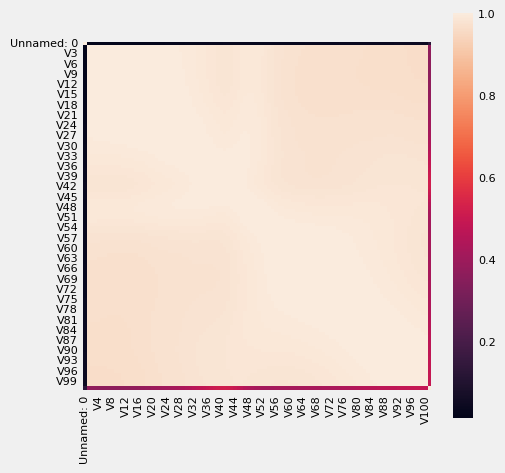

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [78]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
sns.heatmap(
    data      = corr_matrix,
    square    = True,
    ax        = ax
)
ax.tick_params(labelsize=8)


**Se ven variables muy correlacionadas lo que supone un problema a la hora de emplear modelos de regresión lineal.**

# Partición de datos

**Para poder evaluar la capacidad predictiva de cada modelo, se dividen las observaciones disponibles en dos grupos: uno de entrenamiento (70%) y otro de test (30%).**

In [79]:
X = datos.drop(columns='fat')
y = datos['fat']
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.7,
                                        random_state = 1234,
                                        shuffle      = True
                                    )


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Escalado

Los modelos de regresión lineal con regularización Ridge, Lasso y Elastic Net penalizan la magnitud de los coeficientes del modelo, por lo que **es necesario que todos los predictores estén en la misma escala**. Para ello, se puede emplear estandarización o normalización. En este ejemplo se utiliza **estandarización**.



In [80]:
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Mínimos cuadrados (OLS)

**Se crea y entrena un modelo de regresión lineal usando los datos de entrenamiento.**

In [81]:
# Creación y entrenamiento del modelo
# ==============================================================================
modelo = LinearRegression()
modelo.fit(X=X_train, y=y_train)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


LinearRegression()

**Se extraen los coeficientes del modelo y se grafican para observar el peso de cada variable predictora.**

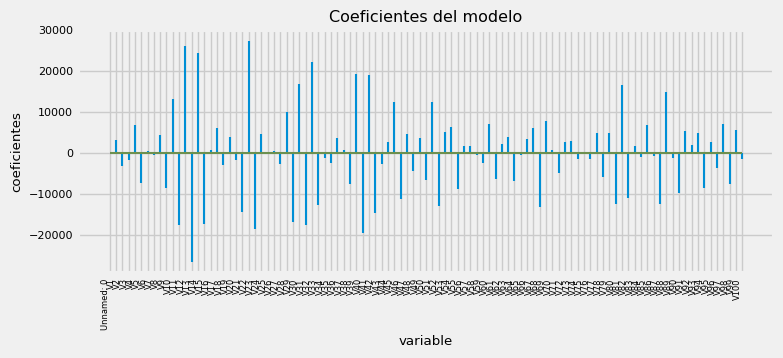

In [82]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': modelo.coef_.flatten()}
                  )

fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');


**Se generan predicciones sobre los datos de prueba para evaluar el comportamiento del modelo con datos no vistos.**

In [83]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


array([36.89143369, 62.65382063, 61.0611438 ,  9.94625871, 18.12617703,
        6.56399216, 28.42050417,  9.18270202, 15.56860211, 16.51684997])

**Se calcula el RMSE(Raíz del Error Cuadrático Medio) del modelo en test para medir qué tan lejos están las predicciones de los valores reales.**

In [84]:
# Error de test del modelo
# ==============================================================================
rmse_ols = root_mean_squared_error(
            y_true  = y_test,
            y_pred  = predicciones,
           )
print(f"El error (rmse) de test es: {rmse_ols}")


El error (rmse) de test es: 3.85180745467741


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Las predicciones del modelo final se alejan en promedio 3.84 unidades del valor real.**

# Ridge

**Se entrena un modelo Ridge usando validación cruzada para probar distintos valores de alpha y elegir el que produce menor error.**

In [85]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# ==============================================================================
# Por defecto RidgeCV utiliza el neg mean squared error
modelo = RidgeCV(
            alphas           = np.logspace(-20, 2, 200),
            scoring          ='neg_root_mean_squared_error',
            fit_intercept    = True,
            store_cv_results = True
         )

_ = modelo.fit(X = X_train, y = y_train)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Se grafica cómo cambian los coeficientes del modelo Ridge a medida que aumenta alpha, mostrando cómo la regularización los reduce progresivamente hacia cero.**

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


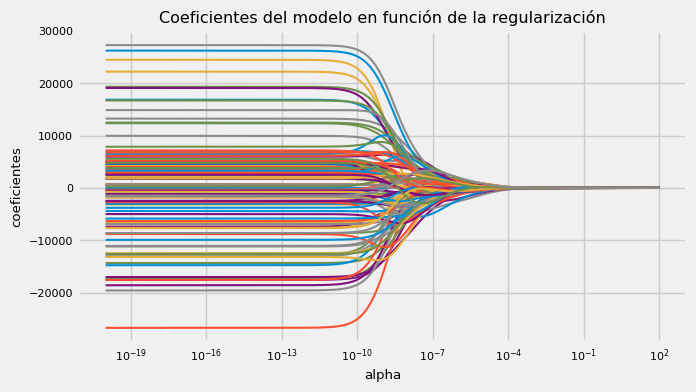

In [86]:
# Evolución de los coeficientes en función de alpha
# ==============================================================================
alphas = modelo.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');
plt.axis('tight')
plt.show()


**Se analiza cómo cambia el error de validación cruzada para cada valor de alpha en Ridge, identificando el alpha con menor RMSE y una alternativa más regularizada usando la regla de una desviación estándar.**


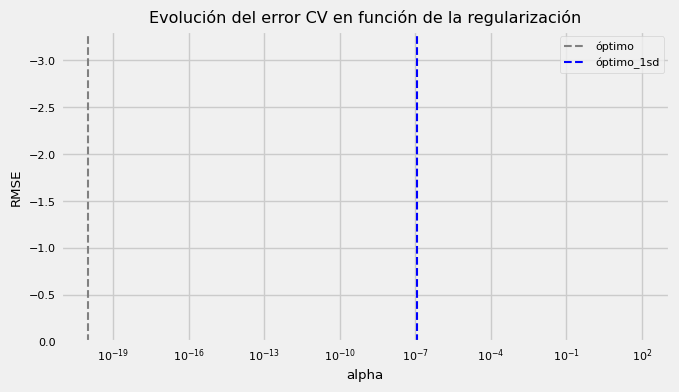

In [87]:
# Evolución del error en función de alpha
# ==============================================================================
# modelo.cv_results_ almacena el resultado de cv para cada valor de alpha.
# Tiene dimensiones (n_samples, n_alphas) o (n_samples, n_targets, n_alphas)
cv_results = modelo.cv_results_
# Se multiplica por -1 para obtener el RMSE positivo
rmse_cv = -1 * cv_results.mean(axis=0)
rmse_sd = cv_results.std(axis=0)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas[np.argmin(rmse_cv)].item()
optimo_1sd   = modelo.alphas[rmse_cv == min_rmse_1sd].item()


# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(modelo.alphas, rmse_cv)
ax.fill_between(
    modelo.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)
ax.axvline(
    x         = optimo_1sd,
    c         = "blue",
    linestyle = '--',
    label     = 'óptimo_1sd'
)
ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend();



# ACLARACION IMPORTANTE:


Al ejecutar el código original se observa que el gráfico muestra valores negativos de RMSE. Esto no es correcto desde el punto de vista conceptual, ya que el RMSE representa una magnitud de error y se calcula como la raíz cuadrada del promedio de errores al cuadrado. Por lo tanto, no puede tomar valores negativos.

Este problema no necesariamente indica que el modelo Ridge esté mal entrenado, sino que hay una diferencia en cómo se están interpretando los resultados almacenados en `cv_results_`. En particular, al usar métricas como `neg_root_mean_squared_error`, scikit-learn puede trabajar internamente con valores negativos porque los modelos de validación cruzada buscan maximizar una puntuación. Sin embargo, para analizar el error del modelo, el RMSE debe presentarse como un valor positivo.

Por este motivo, se propone una versión corregida del código para calcular y graficar correctamente el RMSE en función de `alpha`.

#MODELO CORREGIDO

Entrenamos nuevamente el modelo RidgeCV, quitando el parámetro `scoring='neg_root_mean_squared_error'`. De esta forma, `cv_results_` almacena errores cuadráticos positivos y luego podemos aplicar la raíz cuadrada para calcular correctamente el RMSE.

In [88]:
# Creación y entrenamiento del modelo RidgeCV
# ==============================================================================

modelo = RidgeCV(
    alphas = np.logspace(-20, 2, 200),
    fit_intercept = True,
    store_cv_results = True
)

modelo.fit(X = X_train, y = y_train)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


RidgeCV(alphas=array([1.00000000e-20, 1.28989026e-20, 1.66381689e-20, 2.14614120e-20,
       2.76828663e-20, 3.57078596e-20, 4.60592204e-20, 5.94113398e-20,
       7.66341087e-20, 9.88495905e-20, 1.27505124e-19, 1.64467618e-19,
       2.12145178e-19, 2.73644000e-19, 3.52970730e-19, 4.55293507e-19,
       5.87278661e-19, 7.57525026e-19, 9.77124154e-19, 1.26038293e-18,
       1.62575567e-18, 2.09704640e-1...
       2.86606762e-01, 3.69691271e-01, 4.76861170e-01, 6.15098579e-01,
       7.93409667e-01, 1.02341140e+00, 1.32008840e+00, 1.70276917e+00,
       2.19638537e+00, 2.83309610e+00, 3.65438307e+00, 4.71375313e+00,
       6.08022426e+00, 7.84282206e+00, 1.01163798e+01, 1.30490198e+01,
       1.68318035e+01, 2.17111795e+01, 2.80050389e+01, 3.61234270e+01,
       4.65952567e+01, 6.01027678e+01, 7.75259749e+01, 1.00000000e+02]),
        store_cv_results=True)

En esta sección se analiza la evolución del error de validación cruzada para cada valor de `alpha` en el modelo Ridge corregido. Como el modelo fue entrenado sin `scoring='neg_root_mean_squared_error'`, los valores almacenados en `cv_results_` corresponden a errores cuadráticos positivos. Por eso se aplica la raíz cuadrada para obtener el RMSE.

Luego se identifica el valor de `alpha` que produce el menor RMSE, es decir, el nivel de regularización óptimo. Además, se calcula una alternativa usando la regla de una desviación estándar, que busca un modelo más regularizado pero con un error todavía cercano al mínimo.

Finalmente, se grafica el RMSE en función de `alpha`, junto con las líneas verticales que indican el `alpha` óptimo y el `alpha_1sd`.

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


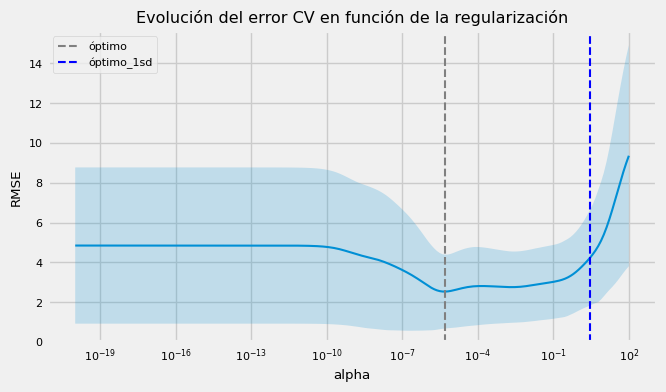

In [89]:
# Evolución del error en función de alpha
# ==============================================================================

# modelo.cv_results_ almacena el resultado de CV para cada valor de alpha.
# En este caso, como no usamos scoring, almacena errores cuadráticos medios.
cv_results = modelo.cv_results_

# Se calcula el RMSE para cada alpha
rmse_cv = np.sqrt(cv_results.mean(axis=0))
rmse_sd = np.sqrt(cv_results).std(axis=0)

# Se identifica el óptimo y el óptimo + 1 desviación estándar
min_rmse    = np.min(rmse_cv)
idx_min     = np.argmin(rmse_cv)
sd_min_rmse = rmse_sd[idx_min]

optimo = modelo.alphas[idx_min].item()

# Regla de 1 desviación estándar:
# se elige el alpha más grande cuyo error esté dentro de min_rmse + sd_min_rmse
limite_1sd = min_rmse + sd_min_rmse
idx_1sd = np.where(rmse_cv <= limite_1sd)[0][-1]
optimo_1sd = modelo.alphas[idx_1sd].item()

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 3.84))

ax.plot(modelo.alphas, rmse_cv)

ax.fill_between(
    modelo.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)

ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)

ax.axvline(
    x         = optimo_1sd,
    c         = "blue",
    linestyle = '--',
    label     = 'óptimo_1sd'
)

ax.set_xscale('log')
ax.set_ylim([0, None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend();


**El gráfico corregido muestra valores positivos de RMSE, lo cual es coherente con la definición de esta métrica**. La c**urva azul representa el RMSE promedio** obtenido por validación cruzada para cada valor de `alpha`.

Se observa que el error disminuye hasta alcanzar un mínimo y luego vuelve a aumentar cuando la regularización es demasiado fuerte. **La línea vertical gris indica el `alpha` óptimo**, mientras que **la línea azul indica una alternativa** más regularizada usando la regla de una **desviación estándar**.

El **área sombreada representa la variabilidad del error**, es decir, el RMSE promedio más/menos una desviación estándar. Cuando esta zona es más amplia, significa que el error varió más entre las particiones de la validación cruzada; cuando es más angosta, el resultado fue más estable.

# Continuamos con el flujo del tutorial usando el modelo RidgeCV corregido

**Se muestra el mejor valor de `alpha` encontrado por RidgeCV, es decir, el nivel de regularización seleccionado automáticamente por el modelo.**

In [90]:
# Mejor valor alpha encontrado
# ==============================================================================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")


Mejor valor de alpha encontrado: 5.0526310653357e-06


**Se grafican los coeficientes finales del modelo Ridge para observar el peso que tiene cada variable predictora luego de aplicar regularización.**

**En comparación al modelo por mínimos cuadrados ordinarios, con ridge, el orden de magnitud de los coeficientes es mucho menor.**

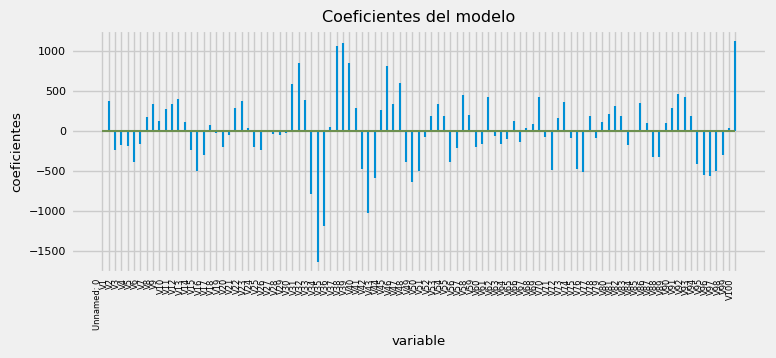

In [91]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': modelo.coef_.flatten()}
                  )

fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');


**Se generan predicciones con el modelo Ridge sobre los datos de prueba para evaluar su desempeño con datos no utilizados en el entrenamiento.**

In [92]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


array([42.83269696, 40.30612286, 50.08641513, 10.42961922, 17.83222606,
        7.38927916, 28.55785418,  8.24650504, 14.67821849, 13.94366015])

**Se calcula el RMSE del modelo Ridge en el conjunto de test, midiendo qué tan alejadas están las predicciones respecto de los valores reales.**

In [93]:
# Error de test del modelo
# ==============================================================================
rmse_ridge = root_mean_squared_error(
                y_true  = y_test,
                y_pred  = predicciones,
             )
print(f"El error (rmse) de test es: {rmse_ridge}")


El error (rmse) de test es: 2.3974240845637107


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Las predicciones del modelo final se alejan en promedio 2.39 unidades del valor real.**

**La modificación no cambió significativamente el modelo final porque se mantuvieron los mismos valores de `alpha`, los mismos datos de entrenamiento y el mismo método RidgeCV. Además, MSE y RMSE están relacionados mediante una raíz cuadrada, por lo que el valor de `alpha` que minimiza el error suele ser el mismo. La corrección afectó principalmente la forma de calcular y visualizar el error en el gráfico, no las predicciones finales del modelo.**

# Lasso

**Se entrena un modelo LassoCV, que prueba distintos valores de `alpha` mediante validación cruzada y selecciona automáticamente el nivel de regularización óptimo.**

In [94]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# ==============================================================================
# Por defecto LassoCV utiliza el mean squared error
modelo = LassoCV(
            alphas = np.logspace(-5, 3, 200),
            cv     = 5,
         )
_ = modelo.fit(X = X_train, y = y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.580438607117685, tolerance: 1.9669414666666671
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0954132078604744, tolerance: 1.9669414666666671
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.8607948043481883, tolerance: 1.9669414666666671
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergen

Cuando se utiliza regularización, es útil evaluar cómo se aproximan a cero los coeficientes a medida que se incrementa el valor de alpha así como la evolución del error de validación cruzada en función del alpha empleado.

**El gráfico muestra cómo cambian los coeficientes del modelo Lasso a medida que aumenta `alpha`; a diferencia de Ridge, Lasso puede llevar varios coeficientes exactamente a cero.**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.729e+00, tolerance: 2.285e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.960e+01, tolerance: 2.285e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.847e+01, tolerance: 2.285e

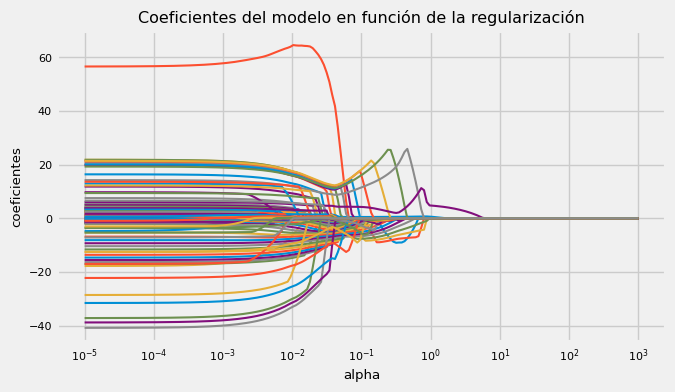

In [95]:
# Evolución de los coeficientes en función de alpha
# ==============================================================================
alphas = modelo.alphas_
coefs = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');


**Puede verse como, a medida que aumenta el valor de alpha, la regularización es mayor y más predictores quedan excluidos (su coeficiente es 0).**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.729e+00, tolerance: 2.285e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.960e+01, tolerance: 2.285e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.847e+01, tolerance: 2.285e

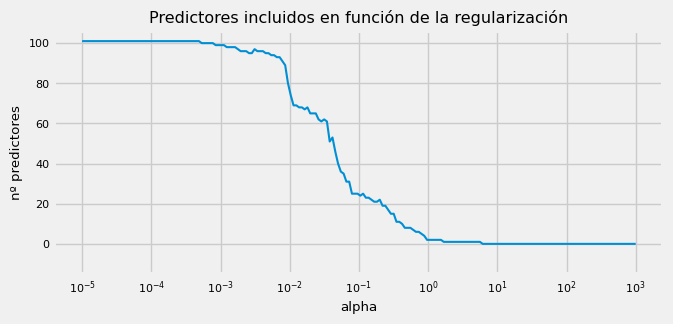

In [96]:
# Número de predictores incluidos (coeficiente !=0) en función de alpha
# ==============================================================================
alphas = modelo.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-15,None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº predictores')
ax.set_title('Predictores incluidos en función de la regularización');


**Este gráfico muestra cuántas variables predictoras quedan activas para cada valor de `alpha`; al aumentar la regularización, Lasso elimina más variables del modelo.**

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return math.isfinite(val)


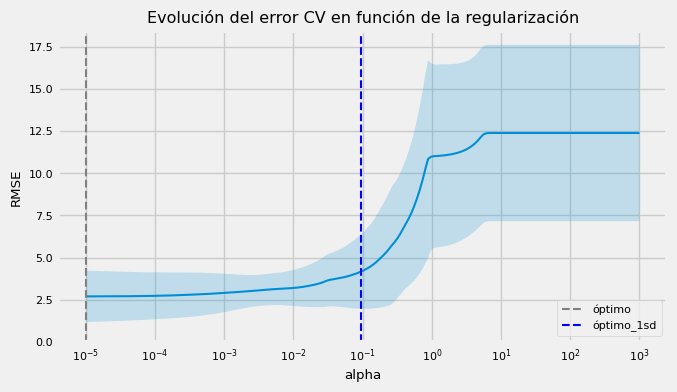

In [97]:
# Evolución del error en función de alpha
# ==============================================================================
# modelo.mse_path_ almacena el mse de cv para cada valor de alpha. Tiene
# dimensiones (n_alphas, n_folds)
mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

# Se aplica la raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas_[np.argmin(rmse_cv)]
optimo_1sd   = modelo.alphas_[rmse_cv == min_rmse_1sd]

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(modelo.alphas_, rmse_cv)
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)
ax.axvline(
    x         = optimo_1sd,
    c         = "blue",
    linestyle = '--',
    label     = 'óptimo_1sd'
)

ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend();


**La curva azul representa el RMSE promedio, el área sombreada muestra la variabilidad del error entre folds, la línea gris marca el `alpha` óptimo y la línea azul el `alpha_1sd`.**

**Se muestra el mejor valor de `alpha` encontrado por LassoCV, es decir, el nivel de regularización que minimiza el error en validación cruzada.**

In [98]:
# Mejor valor alpha encontrado
# ==============================================================================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")


Mejor valor de alpha encontrado: 1e-05


**Se calcula el valor de `alpha_1sd`, una alternativa más regularizada cuyo error sigue estando dentro de una desviación estándar del error mínimo.**

In [99]:
# Mejor valor alpha encontrado + 1sd
# ==============================================================================
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas_[np.argmin(rmse_cv)]
optimo_1sd   = modelo.alphas_[rmse_cv == min_rmse_1sd].item()

print(f"Mejor valor de alpha encontrado + 1 desviación estándar: {optimo_1sd}")


Mejor valor de alpha encontrado + 1 desviación estándar: 0.09547716114208056


**Se entrena nuevamente un modelo Lasso usando `alpha_1sd`, buscando un modelo más simple y regularizado que conserve un error aceptable.**

In [100]:
# Mejor modelo alpha óptimo + 1sd
# ==============================================================================
modelo = Lasso(alpha=optimo_1sd)
modelo.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.141e+02, tolerance: 2.285e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Lasso(alpha=0.09547716114208056)

**Se extraen los coeficientes del modelo Lasso y se conservan solo las variables cuyo coeficiente es distinto de cero.**

In [101]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': modelo.coef_.flatten()}
                  )

# Predictores incluidos en el modelo (coeficiente != 0)
df_coeficientes[df_coeficientes.coef != 0].reset_index(drop=True)


,predictor,coef
0,Unnamed: 0,0.466783
1,V8,-5.209685
2,V9,-7.657133
3,V10,-6.722435
4,V11,-5.944504
5,V12,-5.162439
6,V13,-4.375092
7,V14,-3.541185
8,V15,-2.750643
9,V16,-2.035472


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


De los 100 predictores disponibles, el modelo final solo incluye 24.

**El gráfico muestra los coeficientes finales del modelo Lasso, donde se observa que muchas variables fueron eliminadas al quedar con coeficiente igual a cero**.

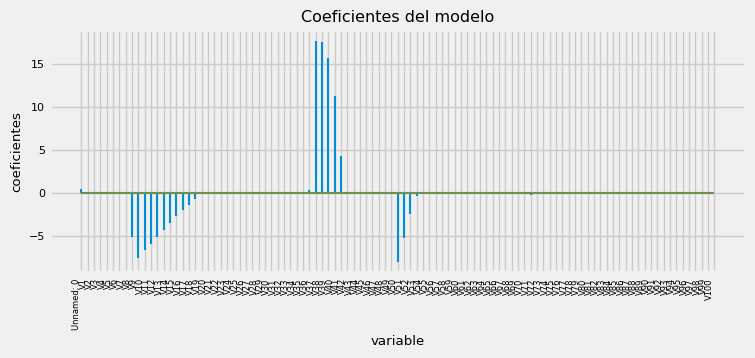

In [102]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');


**Se generan predicciones con el modelo Lasso sobre los datos de prueba para evaluar su desempeño con datos no utilizados durante el entrenamiento.**

In [103]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


array([33.3461004 , 52.74133749, 35.11328019, 12.5778195 , 15.10341565,
        6.03593975, 25.2349857 ,  7.27995703, 13.47743661, 18.11713453])

**Se calcula el RMSE del modelo Lasso en el conjunto de test, midiendo qué tan alejadas están las predicciones respecto de los valores reales.**

In [104]:
# Error de test del modelo
# ==============================================================================
rmse_lasso = root_mean_squared_error(
                y_true = y_test,
                y_pred = predicciones,
             )
print("")
print(f"El error (rmse) de test es: {rmse_lasso}")



El error (rmse) de test es: 3.8457334265514698


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**El modelo Lasso obtiene un RMSE de test de 3.85, lo que indica que sus predicciones se alejan en promedio aproximadamente 3.85 unidades de los valores reales.**

# Elastic net

**Se entrena un modelo ElasticNetCV, que combina regularización Ridge y Lasso, probando distintos valores de `alpha` y `l1_ratio` mediante validación cruzada.**

In [108]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# ==============================================================================
# Por defecto ElasticNetCV utiliza el mean squared error
modelo = ElasticNetCV(
            l1_ratio = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
            alphas   = np.logspace(-10, 3, 200),
            cv       = 5,
         )
_ = modelo.fit(X = X_train, y = y_train)


Se truncaron las últimas líneas 5000 del resultado de transmisión.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 198.12509184394645, tolerance: 1.7671178666666667
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 226.43504270845114, tolerance: 1.7671178666666667
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local

**Se calculan los errores de validación cruzada para cada combinación de `alpha` y `l1_ratio`, convirtiendo el MSE a RMSE para facilitar su interpretación.**

In [109]:
# Evolución del error en función de alpha y l1_ratio
# ==============================================================================
# modelo.mse_path_ almacena el mse de cv para cada valor de alpha y l1_ratio.
# Tiene dimensiones (n_l1_ratio, n_alpha, n_folds)

# Error medio de las 10 particiones por cada valor de alpha y l1_ratio
mean_error_cv = modelo.mse_path_.mean(axis=2)

# El resultado es un array de dimensiones (n_l1_ratio, n_alpha)
# Se convierte en un dataframe
df_resultados_cv = pd.DataFrame(
                        data   = mean_error_cv.flatten(),
                        index  = pd.MultiIndex.from_product(
                                    iterables = [modelo.l1_ratio, modelo.alphas_],
                                    names     = ['l1_ratio', 'modelo.alphas_']
                                 ),
                        columns = ["mse_cv"]
                    )

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending = True)
df_resultados_cv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,l1_ratio,modelo.alphas_,mse_cv,rmse_cv
1360,0.99,3.529707e-08,7.315174,2.704658
1359,0.99,4.102658e-08,7.315188,2.704660
1361,0.99,3.036771e-08,7.315358,2.704692
1358,0.99,4.768612e-08,7.315383,2.704697
1357,0.99,5.542665e-08,7.315744,2.704763
...,...,...,...,...
628,0.70,1.482021e+01,153.374640,12.384452
627,0.70,1.722586e+01,153.374640,12.384452
629,0.70,1.275051e+01,153.374640,12.384452
630,0.70,1.096986e+01,153.374640,12.384452


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Se grafica el menor RMSE obtenido para cada valor de `l1_ratio`, permitiendo observar qué combinación entre Ridge y Lasso produce mejor desempeño.**

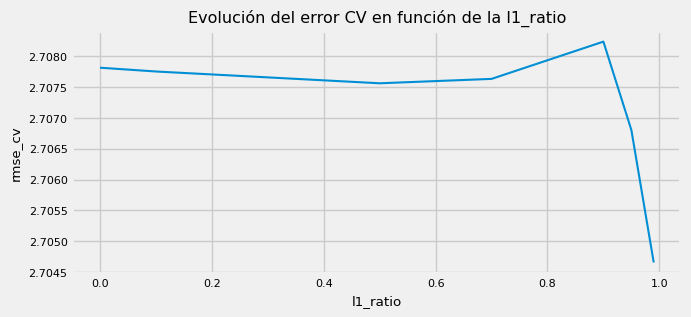

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [110]:
# Mejor valor encontrado para cada l1_ratio
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax = ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv');


**El gráfico muestra cómo cambia el error según el valor de `l1_ratio`. Valores cercanos a 0 se comportan más parecido a Ridge, mientras que valores cercanos a 1 se comportan más parecido a Lasso.**

**Se muestran los mejores valores encontrados de `alpha` y `l1_ratio`, que definen la intensidad de la regularización y la combinación entre Ridge y Lasso.**

In [111]:
# Mejor valor alpha y l1_ratio_ encontrado
# ==============================================================================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")
print(f"Mejor valor de l1_ratio encontrado: {modelo.l1_ratio_}")


Mejor valor de alpha encontrado: 3.5297073027306504e-08
Mejor valor de l1_ratio encontrado: 0.99


**Se extraen los coeficientes finales del modelo Elastic Net para analizar el peso de cada variable predictora.**

In [112]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': modelo.coef_.flatten()}
                  )


**El gráfico muestra los coeficientes del modelo Elastic Net, permitiendo observar qué variables tienen mayor influencia positiva o negativa en la predicción.**

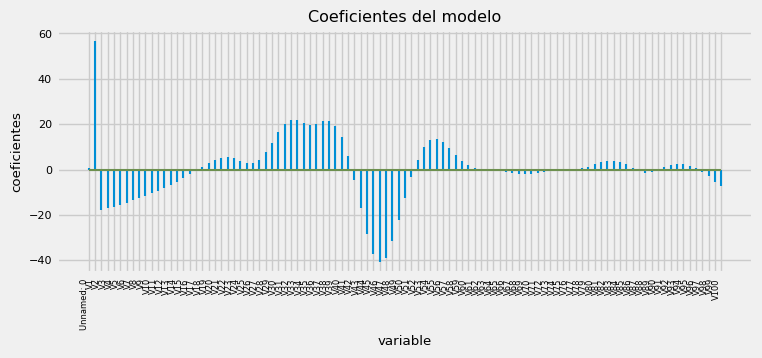

In [113]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');


**Se generan predicciones con el modelo Elastic Net sobre los datos de prueba para evaluar su desempeño con datos no utilizados en el entrenamiento.**

In [114]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Se calcula el RMSE del modelo Elastic Net en el conjunto de test, midiendo qué tan alejadas están sus predicciones respecto de los valores reales.**

In [115]:
# Error de test del modelo
# ==============================================================================
rmse_elastic = root_mean_squared_error(
                y_true  = y_test,
                y_pred  = predicciones,
               )
print("")
print(f"El error (rmse) de test es: {rmse_elastic}")



El error (rmse) de test es: 5.3255454339762665


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**El modelo Elastic Net obtiene un RMSE de test de 5.33, lo que indica que sus predicciones se alejan en promedio aproximadamente 5.33 unidades de los valores reales.**

# Comparación

**Se crea una tabla comparativa con el RMSE de test obtenido por cada modelo: OLS, Ridge, Lasso y Elastic Net.**

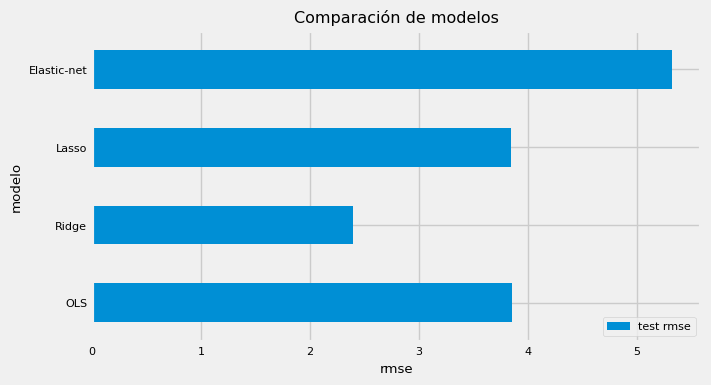

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [116]:
df_comparacion = pd.DataFrame({
                    'modelo': ['OLS', 'Ridge', 'Lasso', 'Elastic-net'],
                    'test rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic]
                 })

fig, ax = plt.subplots(figsize=(7, 3.84))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax)
ax.set_xlabel('rmse')
ax.set_ylabel('modelo')
ax.set_title('Comparación de modelos');


**En la comparación final se observa que el modelo Ridge obtiene el menor RMSE de test, por lo que presenta el mejor desempeño predictivo en este caso. OLS y Lasso muestran errores similares, mientras que Elastic Net obtiene el error más alto. Esto indica que, para este conjunto de datos, la regularización Ridge mejoró la capacidad predictiva del modelo, mientras que Lasso y Elastic Net no lograron reducir el error frente a OLS.**

In [117]:
display(df_comparacion.sort_values('test rmse'))

,modelo,test rmse
1,Ridge,2.397424
2,Lasso,3.845733
0,OLS,3.851807
3,Elastic-net,5.325545


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Aclaración: Es importante ejecutar el notebook completo en orden, ya que los modelos reutilizan nombres de variables como `modelo` y `predicciones`. Si las celdas se ejecutan fuera de orden, algunos resultados pueden quedar sobrescritos y afectar la comparación final.**

# Conclusión

En este trabajo se analizaron distintos métodos de regularización aplicados a modelos de regresión lineal: Ridge, Lasso y Elastic Net. A partir del desarrollo del tutorial, se pudo observar que la regularización permite controlar la complejidad del modelo mediante una penalización sobre los coeficientes, evitando que estos tomen valores excesivamente grandes y ayudando a mejorar la capacidad de generalización.

Primero se entrenó un modelo de regresión lineal tradicional como referencia. Luego se aplicó Ridge, que reduce el tamaño de los coeficientes sin eliminarlos completamente. En este caso, Ridge obtuvo el menor RMSE de test, por lo que fue el modelo con mejor desempeño predictivo.

También se trabajó con Lasso, que además de regularizar puede llevar coeficientes exactamente a cero, funcionando como una forma de selección automática de variables. Sin embargo, en este dataset su error fue similar al de la regresión lineal tradicional y mayor que el de Ridge. Por último, se evaluó Elastic Net, que combina características de Ridge y Lasso, aunque en este caso obtuvo el mayor error de test.

Durante el trabajo también fue necesario revisar y corregir una parte del código relacionada con la representación del RMSE en validación cruzada para Ridge. El gráfico original mostraba valores negativos de RMSE, lo cual no es correcto conceptualmente, ya que el RMSE representa una magnitud de error y debe ser positivo. Esta corrección permitió interpretar mejor la evolución del error en función del parámetro `alpha`.

En conclusión, el modelo Ridge fue el más adecuado para este caso particular, ya que logró reducir el error de predicción respecto a los demás modelos. Además, el trabajo permitió comprender mejor cómo influyen los hiperparámetros de regularización, especialmente `alpha`, en el comportamiento de los coeficientes y en el rendimiento final del modelo.

# Referencias

- Ciencia de Datos. (s.f.). *Regularización Ridge, Lasso y Elastic Net con Python*.  
  https://cienciadedatos.net/documentos/py14-ridge-lasso-elastic-net-python

- Scikit-learn. (s.f.). *Linear models: Ridge, Lasso and Elastic Net*.  
  https://scikit-learn.org/stable/modules/linear_model.html

- Scikit-learn. (s.f.). *RidgeCV*.  
  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html

- Scikit-learn. (s.f.). *LassoCV*.  
  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html

- Scikit-learn. (s.f.). *ElasticNetCV*.  
  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNetCV.html
